# Google Colab Rust Setup

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evcxr/evcxr/blob/main/evcxr_jupyter/samples/evcxr_jupyter_tour_colab.ipynb)

This is the Colab edition of the tour. It stays on Colab's Python kernel and runs evcxr through the `%%rust` cell magic from [colab-rust](https://github.com/xavierforge/colab-rust), a community maintained project. That works on GPU runtimes too, and you can mix Python and Rust cells. Run the next two cells first to set that up. It usually takes well under a minute, or about ten minutes if evcxr has to be built from source.

Note that this notebook is meant for Google Colab: the setup cell installs Rust and evcxr into the runtime, so it shouldn't be run on a local Jupyter. Colab also highlights `%%rust` cells as Python, so Rust keywords won't be coloured.


In [ ]:
!curl -fsSL -o setup.sh https://raw.githubusercontent.com/xavierforge/colab-rust/v0.1.4/setup.sh
!COLAB_RUST_REF=v0.1.4 bash setup.sh

In [2]:
%load_ext colab_rust

✅ colab_rust 0.1.4 loaded — use %%rust in any cell


# Tour of the EvCxR Jupyter Kernel
For those not already familiar with Jupyter notebook, it lets you write code into "cells" like the box below. Cells can alternatively contain markdown, like this text here. Each code cell is compiled and executed separately, but variables, defined functions etc persist between cells. Here, each Rust cell starts with `%%rust`. Everything after that line gets sent to evcxr.

## Printing to outputs and evaluating expressions
Lets print something to stdout and stderr then return a final expression to see how that's presented. Note that stdout and stderr are separate streams, so may not appear in the same order is their respective print statements.

In [3]:
%%rust
println!("Hello world");
eprintln!("Hello error");
format!("Hello {}", "world")

Hello world


Hello error


"Hello world"


## Assigning and making use of variables
We define a variable `message`, then in the subsequent cell, modify the string and finally print it out. We could also do all this in the one cell if we wanted.

In [4]:
%%rust
let mut message = "Hello ".to_owned();

In [5]:
%%rust
message.push_str("world!");

In [6]:
%%rust
message

"Hello world!"


## Defining and redefining functions
Next we'll define a function

In [7]:
%%rust
pub fn fib(x: i32) -> i32 {
    if x <= 2 {0} else {fib(x - 2) + fib(x - 1)}
}

In [8]:
%%rust
(1..13).map(fib).collect::<Vec<i32>>()

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Hmm, that doesn't look right. Lets redefine the function. In practice, we'd go back and edit the function above and reevalute it, but here, lets redefine it in a separate cell.

In [9]:
%%rust
pub fn fib(x: i32) -> i32 {
    if x <= 2 {1} else {fib(x - 2) + fib(x - 1)}
}

In [10]:
%%rust
let values = (1..13).map(fib).collect::<Vec<i32>>();
values

[1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144]


## Spawning a separate thread and communicating with it
We can spawn a thread to do stuff in the background, then continue executing code in other cells.

In [11]:
%%rust
use std::sync::{Mutex, Arc};
let counter = Arc::new(Mutex::new(0i32));
std::thread::spawn({
    let counter = Arc::clone(&counter);
    move || {
        for i in 1..300 {
            *counter.lock().unwrap() += 1;
            std::thread::sleep(std::time::Duration::from_millis(100));
        }
}});

In [12]:
%%rust
*counter.lock()?

15


In [13]:
%%rust
*counter.lock()?

74


## Loading external crates
We can load external crates. This one takes a while to compile, but once it's compiled, subsequent cells shouldn't need to recompile it, so it should be much quicker.

In [14]:
%%rust
:dep base64 = "0.10.1"
base64::encode(&vec![1, 2, 3, 4])

   Compiled 2 crates in 2s

"AQIDBA=="


## Customizing how types are displayed
We can also customize how our types are displayed, including presenting them as HTML. Here's an example where we define a custom display function for a type `Matrix`.

In [15]:
%%rust
use std::fmt::Debug;
pub struct Matrix<T> {pub values: Vec<T>, pub row_size: usize}
impl<T: Debug> Matrix<T> {
    pub fn evcxr_display(&self) {
        let mut html = String::new();
        html.push_str("<table>");
        for r in 0..(self.values.len() / self.row_size) {
            html.push_str("<tr>");
            for c in 0..self.row_size {
                html.push_str("<td>");
                html.push_str(&format!("{:?}", self.values[r * self.row_size + c]));
                html.push_str("</td>");
            }
            html.push_str("</tr>");
        }
        html.push_str("</table>");
        println!("EVCXR_BEGIN_CONTENT text/html\n{}\nEVCXR_END_CONTENT", html);
    }
}

In [16]:
%%rust
let m = Matrix {values: vec![1,2,3,4,5,6,7,8,9], row_size: 3};
m

1,2,3
4,5,6
7,8,9


We can also return images using add-on crates like `evcxr_image`, which adds support for displaying RGB and grayscale images in Evcxr. Note, the version of the `image` crate used must match the version used by `evcxr_image`, otherwise the types will effectively be different and the image won't get displayed.

Note, adding a dependency causes everything to be recompiled. Variables whose types were defined in earlier cells, such as `m` above, can't be kept across the recompile, so evcxr drops them and tells you. If you want to keep such variables, add your dependencies first.


   Compiled 21 crates in 43s

The type of the variable m was redefined, so was lost.


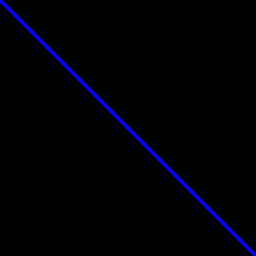

In [17]:
%%rust
:dep image = "0.23"
:dep evcxr_image = "1.1"
use evcxr_image::ImageDisplay;

image::ImageBuffer::from_fn(256, 256, |x, y| {
    if (x as i32 - y as i32).abs() < 3 {
        image::Rgb([0, 0, 255])
    } else {
        image::Rgb([0, 0, 0])
    }
})

## Display of compilation errors
Here's how compilation errors are presented. Here we forgot an & and passed a String instead of an &str.

In [18]:
%%rust
let mut s = String::new();
s.push_str(format!("foo {}", 42));

[E0308] Error: mismatched types
   ╭─[ command_17:1:1 ]
   │
 2 │ s.push_str(format!("foo {}", 42));
   │            ──────────┬──────────  
   │                      ╰──────────── expected `&str`, found `String`
───╯


## Async await
Async functions can be called and the results awaited. Currently this uses Tokio as the executor. The first run of code that uses await will likely be slow while Tokio is compiled. We explicitly add tokio as a dependency so that we can turn on the "full" feature. This is needed for TcpStream. This example also demostrates use of the question mark operator, which upon finding that the result contained an error, prints it to stderr.

In [19]:
%%rust
:dep tokio = {version = "0.2", features = ["full"]}

   Compiled 15 crates in 22s

In [20]:
%%rust
let mut stream : tokio::net::TcpStream = tokio::net::TcpStream::connect("127.0.0.1:99999").await?;

invalid port value


Note, we needed to give an explicit type to the stream variable, because rustc, at least at the time of writing suggests `tokio::net::tcp::TcpStream`, which is private. We need to explicitly provide the public alias in such cases.

Now let's try again with a valid port number. First, make something listen on port 6543. Since we're still on the Python kernel, we can do that from a Python cell.


In [21]:
# Listen on port 6543 and hand the one expected connection to a thread.
import socket
import threading

received = []
server = socket.socket()
server.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
server.bind(("127.0.0.1", 6543))
server.listen(1)

def accept_one():
    conn, _ = server.accept()
    received.append(conn.recv(1024).decode())
    conn.close()
    server.close()

listener = threading.Thread(target=accept_one, daemon=True)
listener.start()
print("listening on 127.0.0.1:6543")


listening on 127.0.0.1:6543


In [22]:
%%rust
let mut stream : tokio::net::TcpStream = tokio::net::TcpStream::connect("127.0.0.1:6543").await?;

In [23]:
%%rust
use tokio::io::AsyncWriteExt;
stream.write(b"Hello, world!\n").await?;

At this point, our listener should have received "Hello, world!". Let's check.


In [24]:
listener.join(timeout=5)
print(received)

['Hello, world!\n']


## Seeing what variables have been defined
We can print a table of defined variables and their types with the :vars command.

In [25]:
%%rust
:vars

Variable,Type
stream,tokio::net::TcpStream
values,Vec<i32>
message,String
counter,Arc<Mutex<i32>>


Other built-in commands can be found via :help

In [26]:
%%rust
:help

:allow_static_linking,Set whether to allow static linking of dependencies (0/1)
:build_env,Set environment variables when building code (key=value)
:cache,"Set cache size in MiB, or 0 to disable."
:clear,"Clear all state, keeping compilation cache"
:clear_cache,Clear the cache used by the :cache command
:codegen_backend,Set/print the codegen backend. Requires nightly
:dep,"Add dependency. e.g. :dep regex = ""1.0"""
:doc,"show the documentation of a variable, keyword, type or module"
:efmt,Set the formatter for errors returned by ?
:env,Set an environment variable (key=value)
:explain,Print explanation of last error
